Số mức xám thật sự xuất hiện L = 256
Min sau cân bằng: 0
Max sau cân bằng: 255


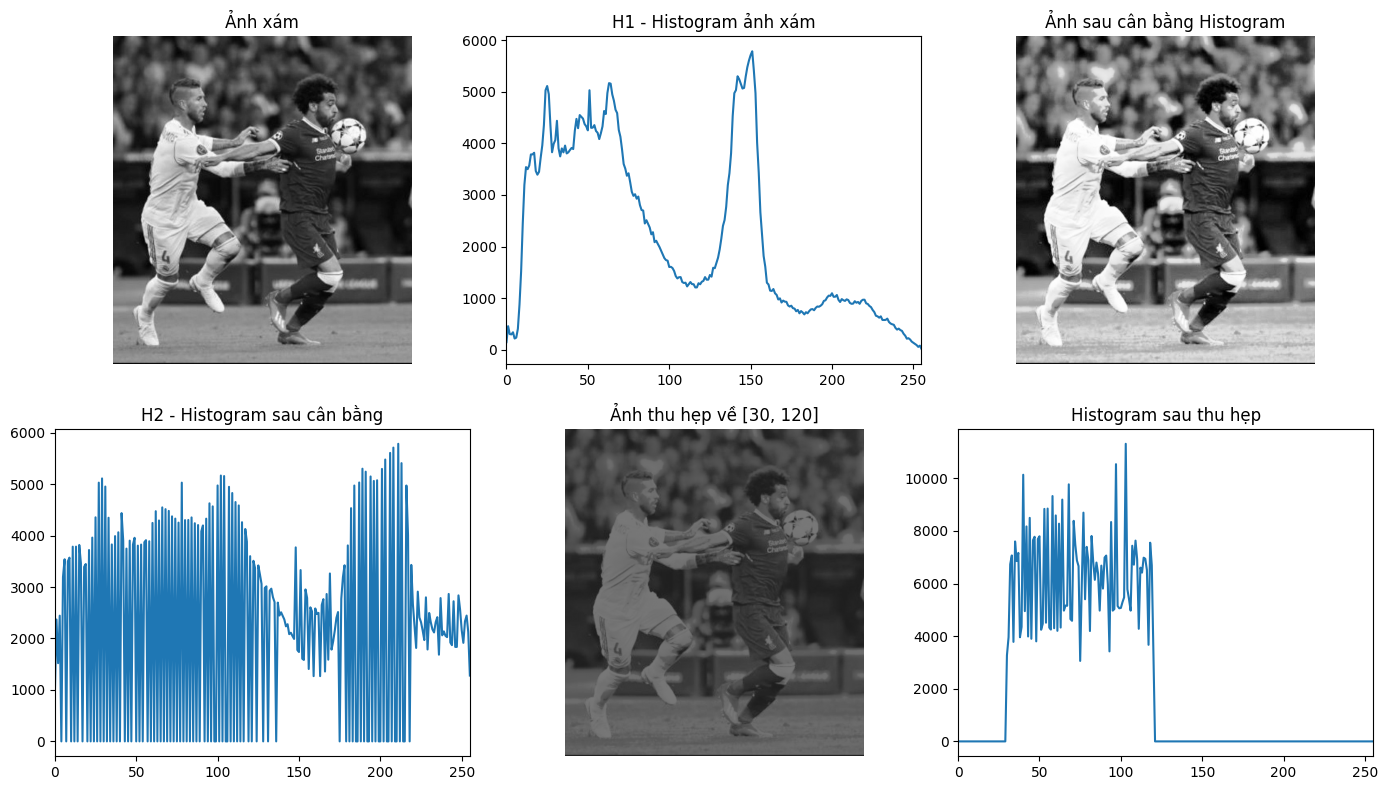

Min gray ban đầu: 0
Max gray ban đầu: 255
Min ảnh sau cân bằng: 0
Max ảnh sau cân bằng: 255
Min ảnh sau thu hẹp: 30
Max ảnh sau thu hẹp: 120
Kết thúc phân tích ảnh  1
Số mức xám thật sự xuất hiện L = 216
Min sau cân bằng: 0
Max sau cân bằng: 215


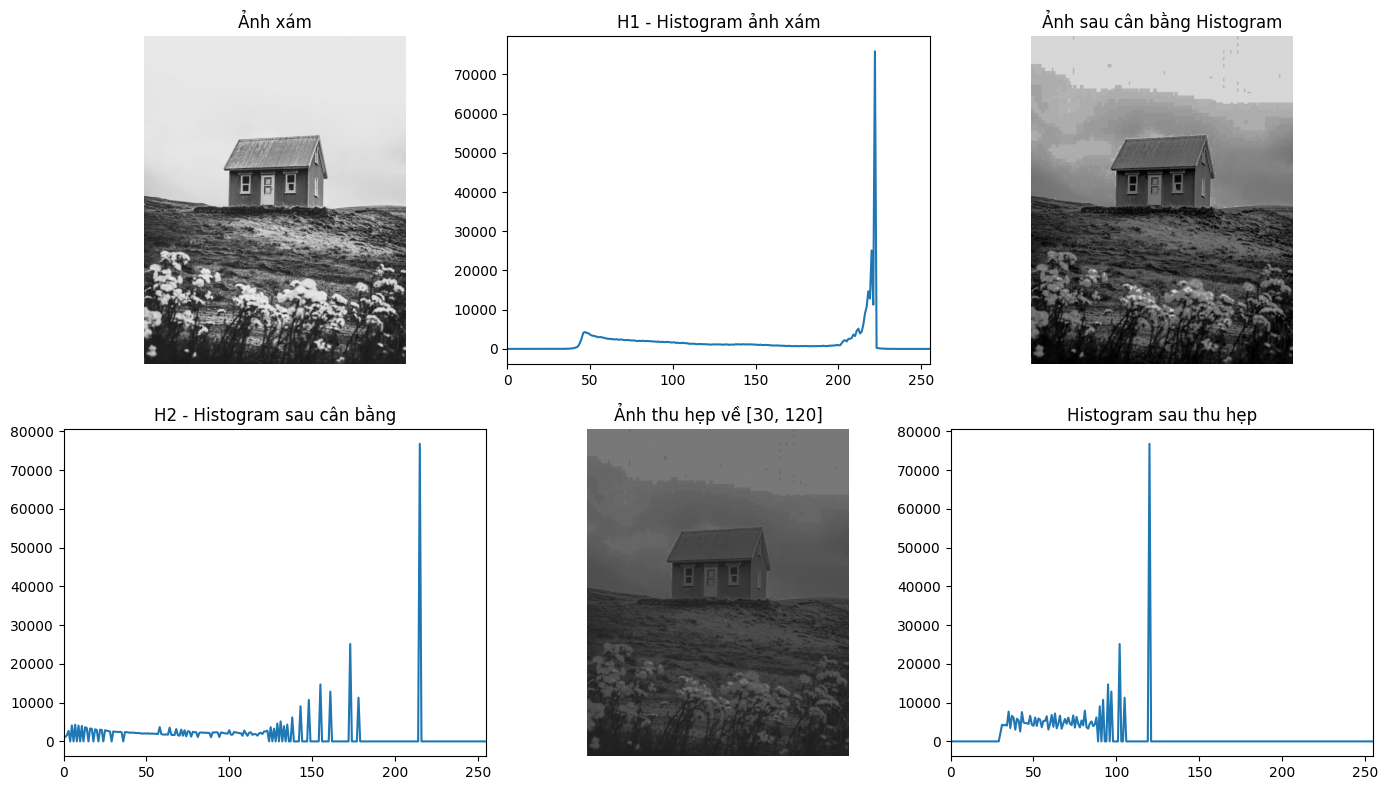

Min gray ban đầu: 20
Max gray ban đầu: 242
Min ảnh sau cân bằng: 0
Max ảnh sau cân bằng: 215
Min ảnh sau thu hẹp: 30
Max ảnh sau thu hẹp: 120
Kết thúc phân tích ảnh  2


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0. Đọc ảnh màu
# =========================
num = 1;
while(num <= 10):
  file_name = f"anh{num}.jpg"
  img = cv2.imread(file_name)

  if img is None:
      raise FileNotFoundError("Không tìm thấy ảnh")

  h, w, c = img.shape

  # =========================
  # 1. Chuyển ảnh màu sang ảnh xám thủ công
  # OpenCV đọc ảnh theo BGR
  # Gray = 0.299R + 0.587G + 0.114B
  # =========================
  gray = np.zeros((h, w), dtype=np.uint8)

  for i in range(h):
      for j in range(w):
          B = img[i, j, 0]
          G = img[i, j, 1]
          R = img[i, j, 2]

          gray_value = 0.299 * R + 0.587 * G + 0.114 * B
          gray[i, j] = int(round(gray_value))

  # =========================
  # 2. Tính histogram H1 thủ công
  # =========================
  H1 = np.zeros(256, dtype=int)

  for i in range(h):
      for j in range(w):
          intensity = gray[i, j]
          H1[intensity] += 1

  # =========================
  # 3. Đếm số mức xám thật sự xuất hiện
  # =========================
  L = 0

  for k in range(256):
      if H1[k] > 0:
          L += 1

  print("Số mức xám thật sự xuất hiện L =", L)

  # =========================
  # 4. Tính PDF
  # =========================
  N = h * w

  pdf = np.zeros(256, dtype=float)

  for k in range(256):
      pdf[k] = H1[k] / N

  # =========================
  # 5. Tính CDF
  # =========================
  cdf = np.zeros(256, dtype=float)

  cdf[0] = pdf[0]

  for k in range(1, 256):
      cdf[k] = cdf[k - 1] + pdf[k]

  # =========================
  # 6. Mapping mức xám cũ sang mức xám mới
  # s_k = round((L - 1) * CDF(k))
  # với L là số mức xám thật sự xuất hiện
  # =========================
  mapping = np.zeros(256, dtype=np.uint8)

  for k in range(256):
      mapping[k] = int(round((L - 1) * cdf[k]))

  # =========================
  # 7. Tạo ảnh sau cân bằng histogram
  # =========================
  equalized = np.zeros((h, w), dtype=np.uint8)

  for i in range(h):
      for j in range(w):
          old_value = gray[i, j]
          equalized[i, j] = mapping[old_value]

  # =========================
  # 8. Tính histogram H2 sau cân bằng
  # =========================
  H2 = np.zeros(256, dtype=int)

  for i in range(h):
      for j in range(w):
          intensity = equalized[i, j]
          H2[intensity] += 1

  # =========================
  # 9. Thu hẹp ảnh sau cân bằng về khoảng [30, 120]
  # Công thức tổng quát:
  # s = ((smax - smin) / (rmax - rmin)) * (r - rmin) + smin
  # =========================
  smin = 30
  smax = 120

  # Tìm rmin, rmax thật sự của ảnh sau cân bằng
  rmin = equalized[0, 0]
  rmax = equalized[0, 0]

  for i in range(h):
      for j in range(w):
          value = equalized[i, j]

          if value < rmin:
              rmin = value

          if value > rmax:
              rmax = value

  print("Min sau cân bằng:", rmin)
  print("Max sau cân bằng:", rmax)

  narrow = np.zeros((h, w), dtype=np.uint8)

  for i in range(h):
      for j in range(w):
          r = equalized[i, j]

          if rmax == rmin:
              s = smin
          else:
              s = ((smax - smin) / (rmax - rmin)) * (r - rmin) + smin

          narrow[i, j] = int(round(s))

  # =========================
  # 10. Histogram sau khi thu hẹp
  # =========================
  H3 = np.zeros(256, dtype=int)

  for i in range(h):
      for j in range(w):
          intensity = narrow[i, j]
          H3[intensity] += 1

  # =========================
  # 11. Hiển thị kết quả
  # =========================
  plt.figure(figsize=(14, 8))

  plt.subplot(2, 3, 1)
  plt.imshow(gray, cmap="gray")
  plt.title("Ảnh xám")
  plt.axis("off")

  plt.subplot(2, 3, 2)
  plt.plot(H1)
  plt.title("H1 - Histogram ảnh xám")
  plt.xlim([0, 255])

  plt.subplot(2, 3, 3)
  plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
  plt.title("Ảnh sau cân bằng Histogram")
  plt.axis("off")

  plt.subplot(2, 3, 4)
  plt.plot(H2)
  plt.title("H2 - Histogram sau cân bằng")
  plt.xlim([0, 255])

  plt.subplot(2, 3, 5)
  plt.imshow(narrow, cmap="gray", vmin=0, vmax=255)
  plt.title("Ảnh thu hẹp về [30, 120]")
  plt.axis("off")

  plt.subplot(2, 3, 6)
  plt.plot(H3)
  plt.title("Histogram sau thu hẹp")
  plt.xlim([0, 255])

  plt.tight_layout()
  plt.show()

  # =========================
  # 12. In thông tin kiểm tra
  # =========================
  print("Min gray ban đầu:", gray.min())
  print("Max gray ban đầu:", gray.max())

  print("Min ảnh sau cân bằng:", equalized.min())
  print("Max ảnh sau cân bằng:", equalized.max())

  print("Min ảnh sau thu hẹp:", narrow.min())
  print("Max ảnh sau thu hẹp:", narrow.max())

  print("Kết thúc phân tích ảnh ", num)
  print("======================================")
  num += 1;